# Image models, input fidelity, and replication
**Alvaro Mendizabal · RSNA Knee Abnormality Detection · Stage 27**

This notebook reviews completed image-model experiments through September 22, 2026 UTC. It executes from the public aggregate evidence without AWS credentials, MRI data, or model weights. Replaying this analysis is **not** rerunning private MRI inference. Saved Plotly MIME figures include inline SVG fallbacks.

**Finding:** the preregistered full-Raptor/DINO blend failed replication. A predefined secondary blend is promising but unconfirmed. The dated **0.933 public score belongs to a reproduced multi-model reference ensemble**, not either local blend. No claim of a winning system or clinical validity is made.

In [1]:
import json, math, sys, html
from pathlib import Path
from IPython.display import display
root = Path.cwd()
if not (root / 'reports/image_models/results.json').is_file():
    root = root.parent
D = json.loads((root / 'reports/image_models/results.json').read_text())
sys.path.insert(0, str(root / 'src'))
from rsna_research.image_models import promotion, attention_pool
print('Evidence:', D['as_of_utc'])
print('Cohorts:', D['pilot_studies'], 'pilot /', D['replication_studies'], 'replication; overlap:', D['pilot_overlap'])
print('Scope:', D['evaluation'])

Evidence: 2026-09-22T02:06:39.184113+00:00
Cohorts: 12 pilot / 12 replication; overlap: 0
Scope: Separate-cohort development replication; not untouched holdout, OOF, clinical validation or leaderboard performance.


## 1. Freeze the decision before inspecting secondary variants

The 90/10 full-Raptor/DINO recipe was selected from sixteen retrospective pilot combinations, then frozen. The twelve replication studies were disjoint from that pilot. The primary comparator was fluid-only Raptor. An AUROC loss of at least 0.002 stops the direction, even when Brier error falls. All twelve targets and at least six studies are required for a decision.

In [2]:
base = D['replication'][D['baseline']]
candidate = D['replication'][D['primary_candidate']]
auc_delta = candidate['macro_auc'] - base['macro_auc']
brier_delta = candidate['brier'] - base['brier']
decision = promotion(auc_delta, brier_delta, len(D['per_target']), D['replication_studies'])
assert decision == D['primary_decision'] == 'STOP_FIXED_BLEND_DIRECTION'
print(f'Primary delta: AUROC {auc_delta:+.6f}; Brier {brier_delta:+.6f}')
print('Decision:', decision)
print('No automatic model promotion or submission.')

Primary delta: AUROC -0.003260; Brier -0.007190
Decision: STOP_FIXED_BLEND_DIRECTION
No automatic model promotion or submission.


## 2. Compare systems only on matched rows

The pilot and replication records describe different development cohorts; the chart below shows replication only. Within each cohort, every arm uses the same studies and targets. Lower replication values are not a longitudinal deterioration estimate. The secondary fluid-Raptor/DINO blend was specified before replication, but selecting it after this result creates a **new** hypothesis requiring separate confirmation.

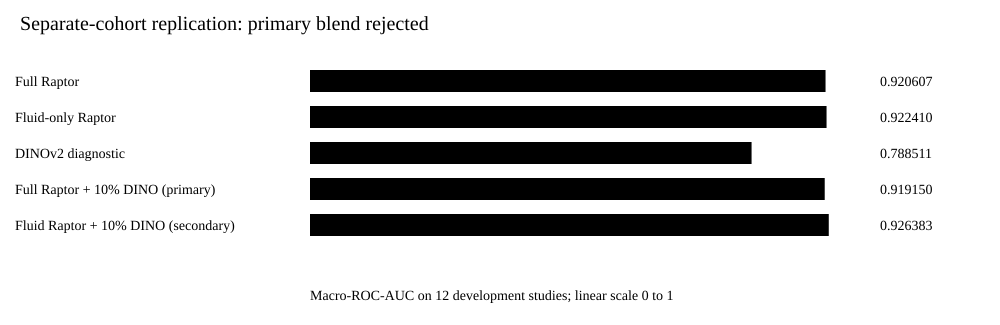

In [3]:
def evidence_chart(title, labels, values, xlabel, upper=1.0):
    # Raw Plotly MIME is offline-safe; the embedded SVG is a static fallback.
    height = 145 + 36 * len(labels)
    numbers = [str(int(v)) if upper == 12 else f'{v:.6f}' for v in values]
    graph = {'data':[{'type':'bar','orientation':'h','y':labels,'x':values,
                       'text':numbers,'textposition':'auto'}],
             'layout':{'title':{'text':title},'width':1000,'height':height,
                       'margin':{'l':300,'r':50,'t':80,'b':65},
                       'xaxis':{'title':{'text':xlabel},'range':[0,upper]},
                       'yaxis':{'autorange':'reversed'},'showlegend':False}}
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="1000" height="{height}" viewBox="0 0 1000 {height}" role="img" aria-label="{html.escape(title)}">',
             f'<rect width="1000" height="{height}" fill="white"/><text x="20" y="30" font-size="20">{html.escape(title)}</text>']
    for i, (label, value) in enumerate(zip(labels, values)):
        y = 70 + 36 * i
        lines += [f'<text x="15" y="{y+16}" font-size="14">{html.escape(label)}</text>',
                  f'<rect x="310" y="{y}" width="{560*value/upper:.2f}" height="22"/>',
                  f'<text x="880" y="{y+16}" font-size="14">{numbers[i]}</text>']
    lines += [f'<text x="310" y="{height-25}" font-size="14">{html.escape(xlabel)}; linear scale 0 to {upper:g}</text>', '</svg>']
    display({'application/vnd.plotly.v1+json':graph,'image/svg+xml':''.join(lines),'text/plain':title}, raw=True)

arms = ['raptor_full42','raptor_fluid24','dino_uniform24','blend_full90_dino10','blend_fluid90_dino10']
labels = ['Full Raptor','Fluid-only Raptor','DINOv2 diagnostic','Full Raptor + 10% DINO (primary)','Fluid Raptor + 10% DINO (secondary)']
evidence_chart('Separate-cohort replication: primary blend rejected', labels,
               [D['replication'][a]['macro_auc'] for a in arms], 'Macro-ROC-AUC on 12 development studies')

## 3. Target support changes the interpretation

Each target has both classes, but some have very few positive cases. AUC is based on positive-negative pairs; one-class samples have undefined AUC, not zero. In the primary paired bootstrap, **536 of 1,000 draws** lacked twelve-target support. The conditional retained-draw interval does not establish a stable improvement. Patellofemoral OA and synovitis remain weak on this selected cohort; they are not proven population-wide error rankings.

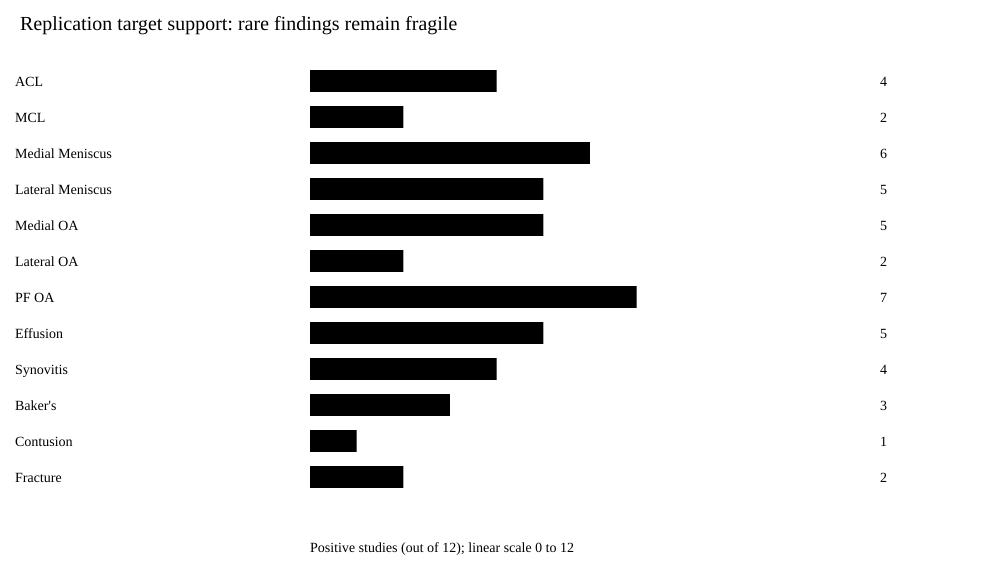

Defined AUC bootstrap draws: 464
Undefined AUC bootstrap draws: 536
Retained-draw AUC interval: [-0.03444919808201058, 0.02872273704304956]


In [4]:
evidence_chart('Replication target support: rare findings remain fragile',
               [r['target'] for r in D['per_target']],
               [r['positive'] for r in D['per_target']], 'Positive studies (out of 12)', upper=12)
print('Defined AUC bootstrap draws:', D['bootstrap']['auc_defined_draws'])
print('Undefined AUC bootstrap draws:', D['bootstrap']['auc_undefined_draws'])
print('Retained-draw AUC interval:', D['bootstrap']['auc_delta_percentile_95'])

## 4. Official scoring is a different evaluation setting

The chart below contains **only public-leaderboard evidence from the same returned page**. It does not contain local cohort metrics. The reference includes multiple public model branches and has not been recreated through independent training. A blank score for the independent-model submission is missing evidence, not zero.

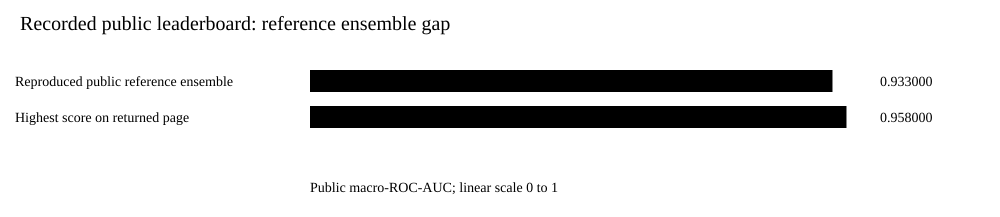

Score snapshot UTC: 2026-09-22T02:06:36.151867+00:00
Comparable recorded gap: 0.025
Independent-model score: None


In [5]:
score = D['public_score_snapshot']
evidence_chart('Recorded public leaderboard: reference ensemble gap',
               ['Reproduced public reference ensemble','Highest score on returned page'],
               [score['reference_ensemble_public_auc'], score['highest_returned_page_auc']],
               'Public macro-ROC-AUC')
print('Score snapshot UTC:', score['utc'])
print(f"Comparable recorded gap: {score['highest_returned_page_auc']-score['reference_ensemble_public_auc']:.3f}")
print('Independent-model score:', score['independent_model_public_score'])

## 5. Engineering that preserved the experimental meaning

The Raptor image encoder produces 1,024-dimensional features. Normalization and target attention are evaluated on all study windows after concatenating encoding microbatches. Full42, fluid24, within36, and fluid-plus-boundary30 are explicit input selections, not independently retrained models. The boundary-30 arm includes non-fluid pixels in mixed triplets.

The synthetic calculation below demonstrates why averaging independently pooled microbatches would be wrong. It is clearly separate from the actual MRI execution record. The real Stage-24 parity experiment reconstructed 98 DICOM inputs and matched the 64-image/42-window reference representation exactly. Stage 26 then reused features without calling the image encoder.

In [6]:
global_result = attention_pool([[0.0], [10.0]], [0.0, 3.0])[0]
independent_average = 5.0
assert global_result > 9 and not math.isclose(global_result, independent_average)
print(f'Synthetic global pooling: {global_result:.6f}; independent-batch average: {independent_average:.6f}')
E = D['execution']
print('Actual Stage-27 execution:', E['gates_passed'], 'gates;', E['regression_tests'], 'regression tests;', E['elapsed_seconds'], 'seconds')
print('Actual input reuse:', E['decoded_files'], 'DICOM files;', E['new_raw_download_files'], 'new raw downloads;', E['encoded_windows'], 'new Raptor windows')
print('Actual fits / GPU / new jobs / submissions:', E['training_fits'], E['gpu_used'], E['new_jobs'], E['submissions_created'])

Synthetic global pooling: 9.525741; independent-batch average: 5.000000
Actual Stage-27 execution: 32 gates; 278 regression tests; 649.953 seconds
Actual input reuse: 1769 DICOM files; 0 new raw downloads; 504 new Raptor windows
Actual fits / GPU / new jobs / submissions: 0 False 0 0


## Decision and next experiment

**Stop the full-Raptor/DINO blend.** Do not tune around its failed primary result. The fixed fluid-Raptor/DINO secondary arm improved both observed cohorts, but requires a final test on eligible studies outside both sets before submission qualification. Inadequate rare-target support would make that result inconclusive, not permission to switch metrics.

A qualified entry also needs exact checkpoint and inference provenance, missing-view behavior, output-schema validation, and a single guarded submission identity. The larger unsolved capability gap is strong grouped/multi-fold training and comparable OOF ensemble evidence. This publication completes the evidence milestone, not the competition objective.

Public aggregate provenance and exact hashes are in `reports/image_models/results.json`. Architecture, attribution, reproduction gaps, and the private/public boundary are in `docs/IMAGE_MODELS.md`. No MRI pixels, report text, study IDs, weights, or private logs are embedded here.

In [7]:
print('RSNA_IMAGE_MODEL_PUBLICATION_COMPLETE')

RSNA_IMAGE_MODEL_PUBLICATION_COMPLETE
